In [3]:
import polars as pl
import datetime
from dataclasses import dataclass
from datetime import timedelta
import pathlib
import joblib
import pandera.polars as pa
import pandera.typing.polars
from pandera.typing.polars import DataFrame
from pandera.typing.polars import Series
import polars as pl
from typing import Annotated
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
#from notebooks.overnight_range_breakout_model import test_start
from typing import Generator

In [5]:
class DayBar(pa.DataFrameModel):
    timestamp: pandera.typing.polars.Series[pl.Datetime("ns", "UTC")]
    open: pandera.typing.polars.Series[float]
    high: pandera.typing.polars.Series[float]
    low: pandera.typing.polars.Series[float]
    close: pandera.typing.polars.Series[float]
CCYS = ['jpy','chf','cad','aud','nzd','eur','gbp']
INVERSE_CCYS = ['chf','jpy','cad']
#NON_MAJORS = ['hkd','mxn','nok','sgd','sek','try','zar']
NON_MAJORS = ['nok','sek','mxn']

In [6]:
#DUKAS
def get_dukas_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\\',f"{pair}_d1_sep_2026.csv")

def read_dukas_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_csv(get_dukas_file_path(ccy))

    df = df.with_columns(
        pl.from_epoch("timestamp", time_unit="ms")
          .dt.cast_time_unit("ns")
          .dt.replace_time_zone("UTC")
    )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)

In [12]:
#OANDA
def get_oanda_file_path(ccy: str):
    if ccy in INVERSE_CCYS:
        pair = f'usd{ccy}'
    else:
        pair = f'{ccy}usd'
    return pathlib.Path(r'D:\Trading\2026\Data\Oanda\\',f"oanda_{pair}.parquet")
def read_oanda_data(ccy: str) -> DataFrame[DayBar]:
    df = pl.read_parquet(get_oanda_file_path(ccy))
    #
    # df = df.with_columns(
    #     pl.from_epoch("timestamp", time_unit="ms")
    #       .dt.cast_time_unit("ns")
    #       .dt.replace_time_zone("UTC")
    # )

    if ccy in INVERSE_CCYS:
        df = df.with_columns(
            (1 / pl.col("open")).alias(f"open"),
            (1 / pl.col("low")).alias("high"),
            (1 / pl.col("high")).alias("low"),
            (1 / pl.col("close")).alias("close"),
        )
    return DayBar.validate(df)

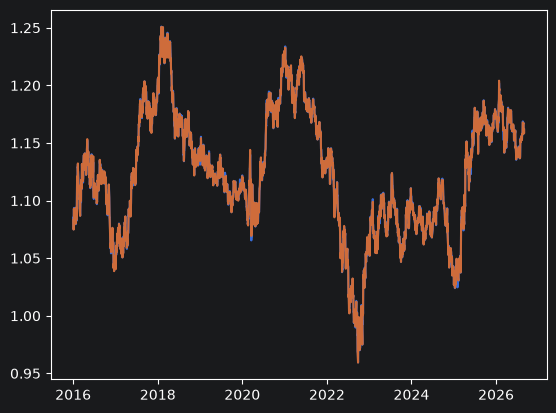

In [95]:
INITIAL_CUT = datetime.datetime(2016, 1, 1, tzinfo=datetime.timezone.utc)
LATER_CUT = datetime.datetime(2026, 9, 1, tzinfo=datetime.timezone.utc)
ccy = "eur"
dukas= read_dukas_data(ccy).filter((pl.col('timestamp') > INITIAL_CUT) & (pl.col('timestamp') < LATER_CUT))
oanda= read_oanda_data(ccy).filter((pl.col('timestamp') > INITIAL_CUT) & (pl.col('timestamp') < LATER_CUT))
plt.plot(dukas['timestamp'], dukas['close'])
plt.plot(oanda['timestamp'], oanda['close'])

In [96]:
dukas['timestamp'][1]

datetime.datetime(2016, 1, 3, 0, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

In [97]:
oanda['timestamp'][1]

datetime.datetime(2016, 1, 4, 22, 0, tzinfo=zoneinfo.ZoneInfo(key='UTC'))

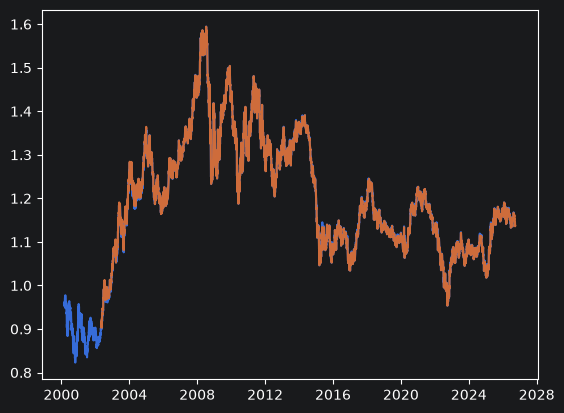

In [98]:
plt.plot(dukas_eurusd['timestamp'], dukas_eurusd['low'])
plt.plot(oanda_eurusd['timestamp'], oanda_eurusd['low'])

In [99]:
dukas[-10:]

timestamp,open,high,low,close
"datetime[ns, UTC]",f64,f64,f64,f64
2026-08-22 00:00:00 UTC,1.16784,1.16784,1.16784,1.16784
2026-08-23 00:00:00 UTC,1.16724,1.16823,1.16724,1.16823
2026-08-24 00:00:00 UTC,1.16823,1.16871,1.16552,1.16678
2026-08-25 00:00:00 UTC,1.16679,1.16795,1.1651,1.16741
2026-08-26 00:00:00 UTC,1.16742,1.16767,1.16419,1.16554
2026-08-27 00:00:00 UTC,1.16554,1.16598,1.16364,1.16535
2026-08-28 00:00:00 UTC,1.16535,1.16589,1.15777,1.15828
2026-08-29 00:00:00 UTC,1.15828,1.15828,1.15828,1.15828
2026-08-30 00:00:00 UTC,1.15758,1.15892,1.15758,1.15886


In [100]:
oanda[-10:]

timestamp,open,high,low,close
"datetime[ns, UTC]",f64,f64,f64,f64
2026-08-18 21:00:00 UTC,1.15763,1.16792,1.15702,1.16774
2026-08-19 21:00:00 UTC,1.1677,1.17105,1.16694,1.16785
2026-08-20 21:00:00 UTC,1.16783,1.17116,1.16688,1.16766
2026-08-23 21:00:00 UTC,1.16766,1.16872,1.16553,1.1664
2026-08-24 21:00:00 UTC,1.16626,1.16798,1.16511,1.16745
2026-08-25 21:00:00 UTC,1.16755,1.16772,1.16422,1.16534
2026-08-26 21:00:00 UTC,1.16522,1.166,1.16366,1.16521
2026-08-27 21:00:00 UTC,1.16514,1.16596,1.15778,1.15821
2026-08-30 21:00:00 UTC,1.15818,1.16207,1.15782,1.16172


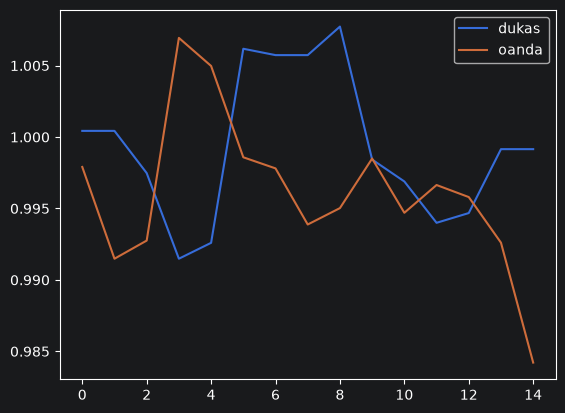

In [94]:
plt.plot(dukas[:15]['close'], label='dukas')
plt.plot(oanda[:15]['close'], label='oanda')
plt.legend()